# Custom detectors

### Working with rate calculator

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from snewpy.rate_calculator import RateCalculator

In [3]:
from snewpy.flavor_transformation import AdiabaticMSW
from snewpy.neutrino import MassHierarchy

# Adiabatic MSW flavor transformation with normal mass ordering
msw_nmo = AdiabaticMSW(mh=MassHierarchy.NORMAL)

In [4]:
rc = RateCalculator()

Using snowglobes_data module ...


In [5]:
rc.detectors.T

,mass,factor,tgt_mass
wc100kt30prct,100.0000,0.111100,11.110000
wc100kt15prct,100.0000,0.111100,11.110000
ar40kt,40.0000,0.025000,1.000000
scint20kt,20.0000,0.142900,2.858000
halo1,0.0790,0.004808,0.000380
halo2,1.0000,0.004808,0.004808
novaND,0.3000,0.107000,0.032100
novaFD,14.0000,0.107000,1.498000
wc100kt30prct_he,100.0000,0.111100,11.110000
ar40kt_he,40.0000,0.025000,1.000000


times and energies for presn models

In [6]:
times = [0.5, 1] * u.s
energies = range(5,50) * u.MeV

In [7]:
from snewpy.rate_calculator import Detector

In [8]:
from snewpy.neutrino import Flavor
from snewpy.rate_calculator import DetectionChannel, SmearingMatrix

In [9]:
xsec_ibd=rc.load_xsec('ibd',Flavor.NU_E_BAR)

In [10]:
x = np.linspace(0, 50, 100)<<u.MeV
y = xsec_ibd(x)
y.unit

/home/temochka2005/Documents/VScodeProjects/.venv/lib/python3.10/site-packages/snewpy/rate_calculator.py:354: RuntimeWarning: divide by zero encountered in log
  return np.interp(np.log(E)/np.log(10), xp, yp, left=0, right=0)*E*1e-38 <<u.cm**2


Unit("cm2")

Text(0, 0.5, 'xsec_ibd, cm2')

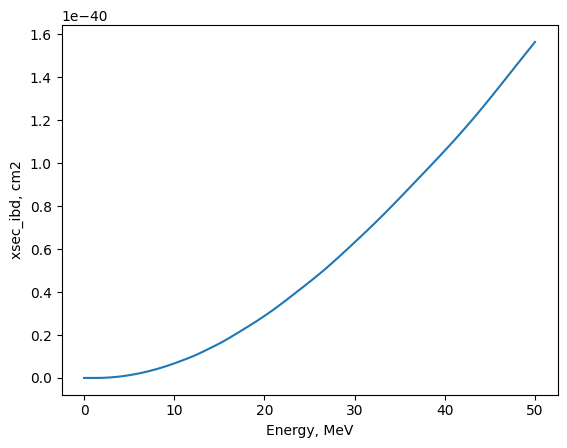

In [11]:
plt.plot(x,y)
plt.xlabel(f'Energy, {x.unit}')
plt.ylabel(f'xsec_ibd, {y.unit}')

### Making smear matrix for IBD at KamLand

In [12]:
e_true = np.linspace(0, 50, 501)<<u.MeV
e_smear = np.linspace(0, 50, 501)<<u.MeV
smear_IBD_KamLand = SmearingMatrix.from_Gaussian(e_true, e_smear, 
                                         mean = lambda e_nu: e_nu - 0.78*u.MeV, 
                                         sigma= lambda e: e * 6.4e-2 / np.sqrt(e.to_value('MeV'))
                                         )

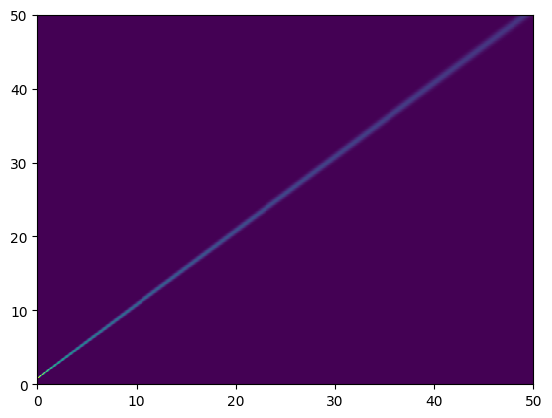

In [13]:
plt.pcolormesh(smear_IBD_KamLand.bins_true, smear_IBD_KamLand.bins_smeared, smear_IBD_KamLand.matrix)
plt.show()

In [14]:
from scipy.interpolate import interp1d

### Setting up custom detectors

In [15]:
def apply_limits(e_min=0*u.MeV, e_max=100*u.MeV):
    def __wrapper(f:callable):
        return lambda e: ((e>=e_min)*(e<=e_max))*f(e)
    return __wrapper

In [16]:
def read_efficiency(fname:str)->callable:
    x,y = np.loadtxt(fname, delimiter=',').T
    eff = interp1d(x,y, bounds_error=False, fill_value=(0, 0))               
    return eff

In [17]:
kamland = Detector(name="KamLAND", mass = 1*u.kt, 
         channels={
    'ibd' : DetectionChannel (flavor=Flavor.NU_E_BAR, 
                              xsec=xsec_ibd, 
                              smearing=smear_IBD_KamLand, 
                              efficiency=apply_limits(0.9*u.MeV, 3.5*u.MeV)(read_efficiency(fname="KamLAND_eff.csv")),
                              weight=0.1429
                              )
                              }
)

In [18]:
borexino = Detector(name="Borexino", mass = 220*u.t, 
         channels={
    'ibd' : DetectionChannel (flavor=Flavor.NU_E_BAR, 
                              xsec=xsec_ibd, 
                              smearing=None, 
                              efficiency=apply_limits(1.8*u.MeV, 8*u.MeV)(read_efficiency(fname="Borexino_eff.csv")),
                              weight=0.1429
                              )
                              }
)

In [19]:
sk_gd = Detector(name="SK-Gd", mass = 50*u.kt, 
         channels={
    'ibd-dc' : DetectionChannel (flavor=Flavor.NU_E_BAR, 
                              xsec=xsec_ibd, 
                              smearing=None, 
                              efficiency=apply_limits(0*u.MeV, 8*u.MeV)(read_efficiency(fname="SK-GD_dc.csv")),
                              weight=0.1429
                              ),
     'ibd-n' : DetectionChannel (flavor=Flavor.NU_E_BAR, 
                              xsec=xsec_ibd, 
                              smearing=None, 
                              efficiency=apply_limits(0*u.MeV, 7*u.MeV)(read_efficiency(fname="SK-Gd_n.csv")),
                              weight=0.1429
                              )
                              }
)

### Plotting event rates at custom detectors from Odrzywolek_2010 model

In [20]:
from snewpy.models.presn import Odrzywolek_2010  

In [21]:
model = Odrzywolek_2010(progenitor_mass=15*u.Msun)

In [22]:
t=np.geomspace(-2*u.day,-1*u.minute, 1001)<<u.s
E=np.linspace(0,8,201)<<u.MeV

In [23]:
from snewpy.flux import Container

In [24]:
flux_nh = model.get_flux(t,E, distance=200*u.pc, flavor_xform=AdiabaticMSW(mh=MassHierarchy.NORMAL))
flux_ih = model.get_flux(t,E, distance=200*u.pc, flavor_xform=AdiabaticMSW(mh=MassHierarchy.INVERTED))

In [25]:
def plot_events(detector:Detector, flux:Container, **kwargs):
    label = kwargs.get('label','')
    for name,n_events in detector.run(flux=flux).items(): 
        summed_n_events = n_events.integrate_or_sum("energy")
        x = summed_n_events.time
        y = summed_n_events.array.squeeze()<<u.Unit("1/h")
        kwargs['label'] = label+' '+name
        plt.plot(x,y, **kwargs)
        
    plt.xlim(x[0].value, x[-1].value)
    # plt.ylim(1e-2,1e3)
    plt.xlabel(f'Time to supernova, {x.unit}')
    plt.ylabel(f'Event rate in {detector.name}, {y.unit}')
    plt.grid(ls=':')
    print(summed_n_events.integrate("time", [np.min(x), np.max(x)]<<u.s).array.squeeze())

In [26]:
def calc_events(detector:Detector, flux:Container, label):
    """Calc events and save them as .txt"""
    for name,n_events in detector.run(flux=flux).items(): 
        summed_n_events = n_events.integrate_or_sum("energy")
        x = summed_n_events.time << u.s
        y = summed_n_events.array.squeeze()<<u.Unit("1/s")
        np.savetxt(f'events/{detector.name}_{name}_{label}.txt', (x,y))       

/home/temochka2005/Documents/VScodeProjects/.venv/lib/python3.10/site-packages/snewpy/rate_calculator.py:354: RuntimeWarning: divide by zero encountered in log
  return np.interp(np.log(E)/np.log(10), xp, yp, left=0, right=0)*E*1e-38 <<u.cm**2


19.295800899759115
5.415622235768647


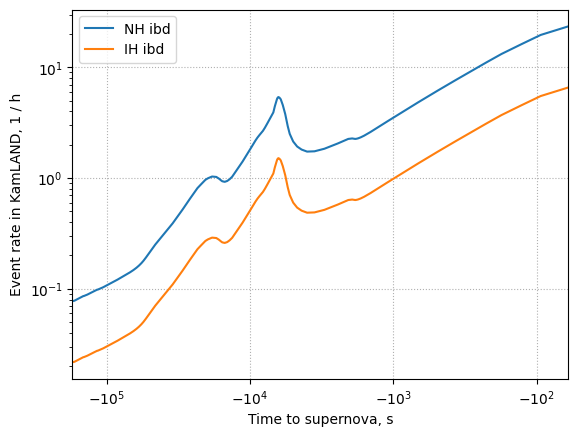

6.319908171971904
1.7737659816221605


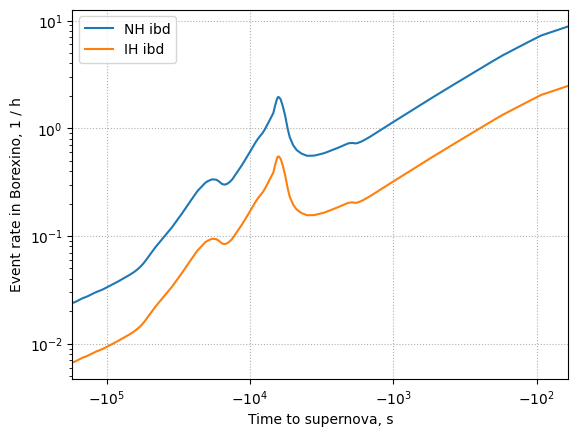

141.75691731198182
39.78595744519573


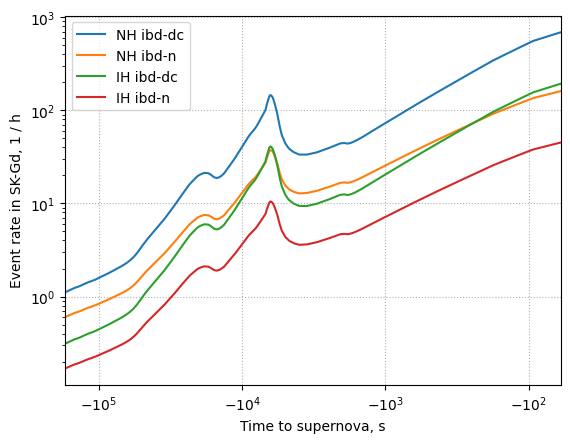

In [27]:
for det in [kamland, borexino, sk_gd]:
    calc_events(det, flux_nh, label='NH')
    calc_events(det, flux_nh, label='IH')
    
    plot_events(det, flux_nh, label='NH')
    plot_events(det, flux_ih, label='IH')
    plt.legend()
    plt.yscale("log")
    plt.xscale("symlog")
    plt.show()

Text(0, 0.5, 'SK-Gd eff')

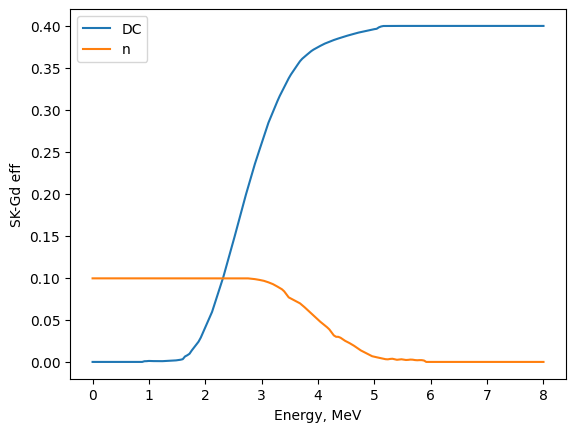

In [28]:
plt.plot(E, sk_gd.channels["ibd-dc"].efficiency(E), label="DC")
plt.plot(E, sk_gd.channels["ibd-n"].efficiency(E), label="n")
plt.legend()
plt.xlabel(f"Energy, {E.unit}")
plt.ylabel("SK-Gd eff")

### Getting distribution and sampling some

In [29]:
import sn_stat

In [30]:
n_events_nh = sk_gd.run(flux=flux_nh)["ibd-n"]
n_events_ih = sk_gd.run(flux=flux_ih)["ibd-n"]

n_events_nh

d2NdEdT (1, 1001, 201) [1 / (MeV s)]: <1 flavor(2;2) x 1001 time(-172800.0 s;-60.0 s) x 201 energy(0.0 MeV;8.0 MeV)>

In [31]:
summed_n_events_nh = n_events_nh.integrate_or_sum("energy")
summed_n_events_ih = n_events_ih.integrate_or_sum("energy")

In [32]:
summed_n_events_nh.integrate('time',[-1*u.hour, -1*u.minute]<<u.s).array.squeeze()

<Quantity 25.68053518>

In [33]:
rate = sn_stat.log_rate(np.loadtxt('events/KamLAND_ibd_NH.txt'))

In [34]:
x = np.linspace(*rate.range,10001)
y = rate(x)

In [35]:
rate.total()

10.690260674075423

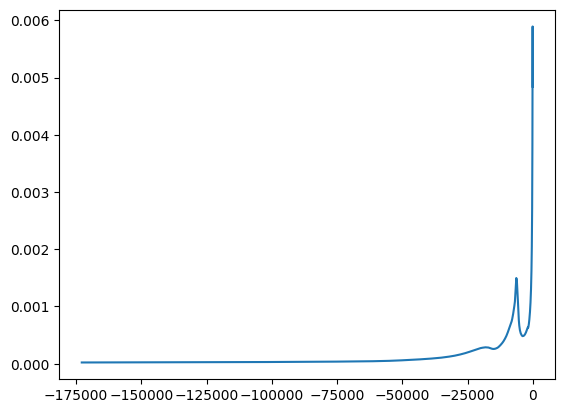

In [36]:
plt.plot(x,y)
plt.show()

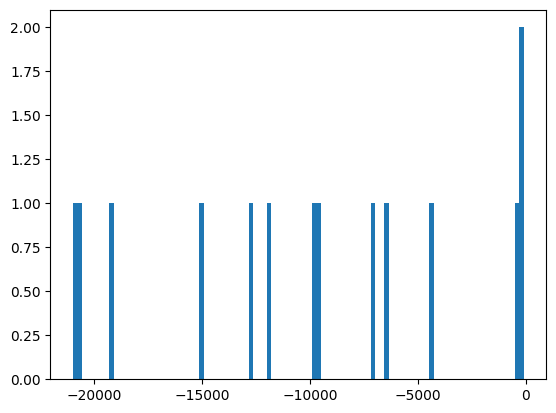

In [37]:
ts = sn_stat.Sampler(rate*1,[-25000,-60]).sample()

plt.hist(ts, bins=100);

### Uploading models of csn to plot flux

In [38]:
from snewpy.models.ccsn import Bollig_2016
Bollig_2016.param

{'progenitor_mass': <Quantity [11.2, 27. ] solMass>, 'eos': ['LS220']}

In [39]:
from snewpy.models.ccsn import Fornax_2021
Fornax_2021.param 

{'progenitor_mass': <Quantity [12.  , 13.  , 14.  , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  ,
            21.  , 22.  , 23.  , 25.  , 26.  , 26.99] solMass>}

In [40]:
Bollig_2016_model = Bollig_2016(progenitor_mass=27*u.Msun)
Bollig_2016_model

**Bollig_2016 Model**

|Parameter|Value|
|:--------|:----:|
|EOS | LS220 |
|Progenitor mass | $27$ $\mathrm{M_{\odot}}$|

In [41]:
Fornax_2021_model = Fornax_2021(progenitor_mass=25*u.Msun)
Fornax_2021_model

**Fornax_2021 Model**

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $25$ $\mathrm{M_{\odot}}$|

times + energies for csn

In [42]:
times    = np.linspace(0,15,2001)<<u.second
energies = np.linspace(0,50,2001)<<u.MeV

getting flux at 10 kpc for every model in NH and IH

In [43]:
flux_nh_Bollig_2016_model = Bollig_2016_model.get_flux(t = times,E = energies, distance=10*u.kpc, flavor_xform=AdiabaticMSW(mh=MassHierarchy.NORMAL))
flux_ih_Bollig_2016_model = Bollig_2016_model.get_flux(t = times,E = energies, distance=10*u.kpc, flavor_xform=AdiabaticMSW(mh=MassHierarchy.INVERTED))

/home/temochka2005/Documents/VScodeProjects/.venv/lib/python3.10/site-packages/snewpy/models/base.py:303: RuntimeWarning: divide by zero encountered in log
  - loggamma(1+a) + a*np.log(E) - (1+a)*(E/Ea)) / (u.erg * u.s)


In [44]:
flux_nh_Fornax_2021_model = Fornax_2021_model.get_flux(t = times,E = energies, distance=10*u.kpc, flavor_xform=AdiabaticMSW(mh=MassHierarchy.NORMAL))
flux_ih_Fornax_2021_model = Fornax_2021_model.get_flux(t = times,E = energies, distance=10*u.kpc, flavor_xform=AdiabaticMSW(mh=MassHierarchy.INVERTED))

In [45]:
flux_ih_Fornax_2021_model

d2FdEdT (4, 2001, 2001) [1 / (MeV s m2)]: <4 flavor(0;3) x 2001 time(0.0 s;15.0 s) x 2001 energy(2.220446049250313e-16 MeV;50.0 MeV)>

Bollig 2016: csn model plots

0.36286012736397755
0.38666022137507533


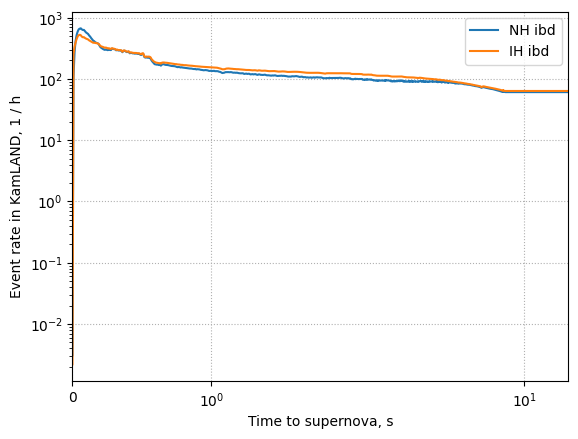

1.8445248187264764
1.8440608689177354


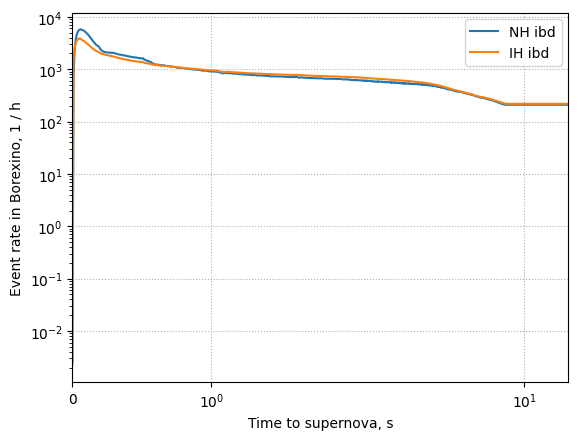

2.4706551555632
2.620524226715722


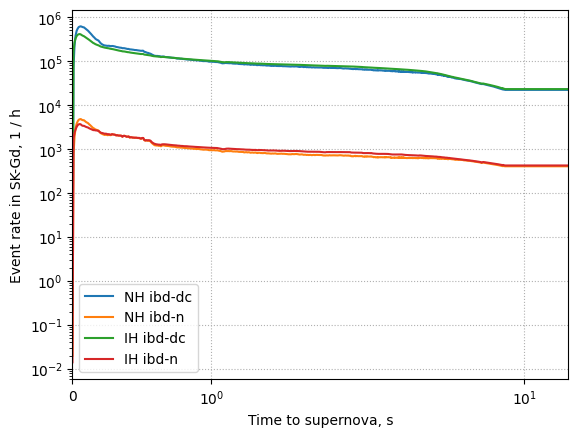

In [46]:
for det in [kamland, borexino, sk_gd]:
    calc_events(det, flux_nh_Bollig_2016_model, label='NH')
    calc_events(det, flux_ih_Bollig_2016_model, label='IH')
    
    plot_events(det, flux_nh_Bollig_2016_model, label='NH')
    plot_events(det, flux_ih_Bollig_2016_model, label='IH')
    plt.legend()
    plt.yscale("log")
    plt.xscale("symlog")
    plt.show()

Fornax 2021: csn model plots

0.7980514786541232
0.8398320025229277


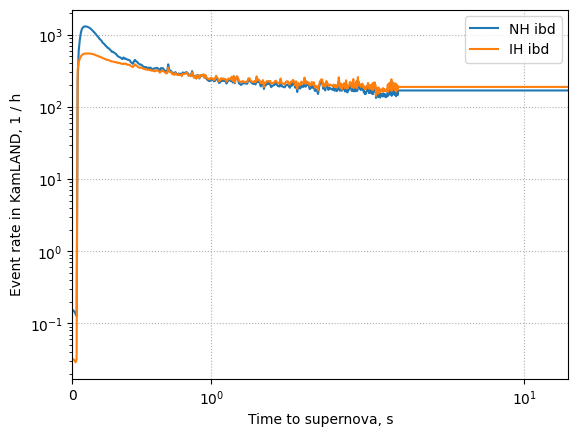

4.880002747157939
3.9907556793017447


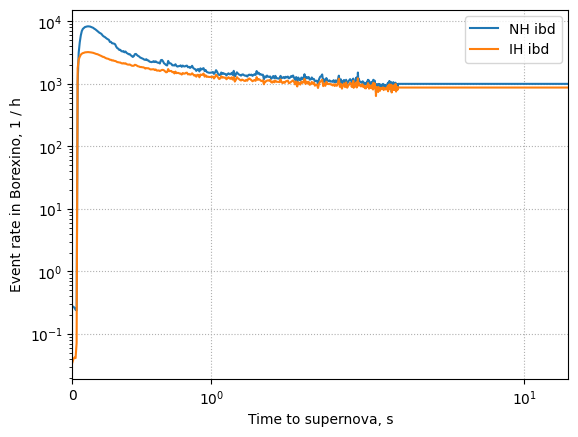

5.572611670655977
5.706860612950162


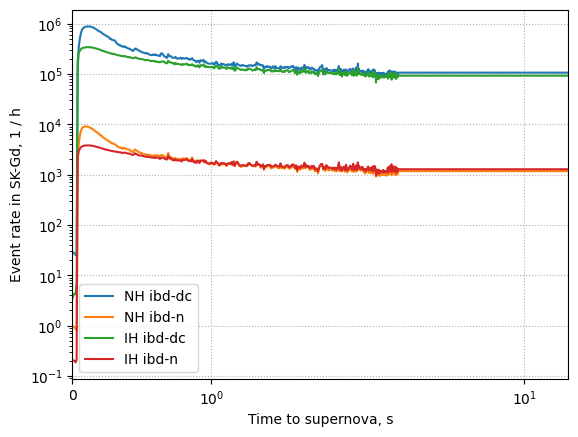

In [47]:
for det in [kamland, borexino, sk_gd]:
    calc_events(det, flux_nh_Fornax_2021_model, label='NH')
    calc_events(det, flux_ih_Fornax_2021_model, label='IH')
    
    plot_events(det, flux_nh_Fornax_2021_model, label='NH')
    plot_events(det, flux_ih_Fornax_2021_model, label='IH')
    plt.legend()
    plt.yscale("log")
    plt.xscale("symlog")
    plt.show()